In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [44]:
df_temp = pd.read_csv('/content/drive/MyDrive/Machine Learning/Projects/Real Estate Capstone Project/DataSets/Done_EDA/Real_Estate_EDA.csv')
df = pd.read_csv('/content/drive/MyDrive/Machine Learning/Projects/Real Estate Capstone Project/DataSets/Done_EDA/final_Real_Estate_EDA.csv')
df_copy = df.copy()
df.head()

,bhk,price,age_of_property,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities,age_category
0,3.00,2.05,15.00,Middle,Moroccan Cooperative,3.00,3.00,3.00,1.00,kaggle,Goregaon East,1862.00,1425.00,True,Semi Furnished,11009.67,4,NaN,NaN,Mid (5-15)
1,1.00,1.33,1.00,Lower,Rajesh White City,1.00,2.00,0.00,1.00,kaggle,Kandivali East,790.00,479.00,True,Unfurnished,16835.44,1,NaN,NaN,New (0-5)
2,3.00,7.30,10.00,Lower,Oberoi Esquire,3.00,2.00,0.00,2.00,kaggle,Goregaon East,1430.00,1330.00,True,Unfurnished,51048.95,3,NaN,NaN,Mid (5-15)
3,3.00,7.60,4.00,Higher,Oberoi Esquire,3.00,4.00,0.00,3.00,kaggle,Goregaon East,2195.00,1400.00,True,Semi Furnished,34624.15,5,NaN,NaN,New (0-5)
4,2.00,3.20,3.00,Lower,Ajmera Zeon,2.00,2.00,1.00,1.00,kaggle,Wadala East,960.00,860.00,True,Unfurnished,33333.33,3,NaN,NaN,New (0-5)


In [45]:
with pd.option_context("display.max_rows", None):
  display(df.groupby('location')['price'].mean().sort_index())

,price
location,
Agripada,4.24
Andheri,3.47
Andheri East,2.43
Andheri West,4.82
Antop Hill,1.63
Anushakti Nagar,3.62
Asalpha,0.67
Bandra,21.01
Bandra East,6.59


In [46]:
df[df['location']=='Worli Seaface']['price'].max()

98.61

## Age of property nan values

In [47]:
# Change pandas display format to show regular floats instead of scientific notation
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [48]:
# identifying the wrongly filled rows (age=0 from kaggle source)
mask = (df['age_of_property'] == 0) & (df['source'] == 'kaggle')
print(mask.sum())

647


In [49]:
# filling those specific rows using location median
location_median = df[df['age_of_property'] != 0].groupby('location')['age_of_property'].median()
df.loc[mask, 'age_of_property'] = df.loc[mask, 'location'].map(location_median)

In [50]:
# Filling Remaining rows with global median
global_median = df[df['age_of_property'] != 0]['age_of_property'].median()
df['age_of_property'] = df['age_of_property'].replace(0, np.nan).fillna(global_median)

In [51]:
# updating category
df['age_category'] = pd.cut(df['age_of_property'],
                             bins=[-1, 1, 5, 15, 100],
                             labels=['New', 'Relatively New', 'Mid Age', 'Old'])

print(df['age_category'].isna().sum())
print(df['age_category'].value_counts())

0
age_category
Relatively New    4650
Mid Age           3088
New               1471
Old                841
Name: count, dtype: int64


# price

Number of price outliers (IQR): 831
Upper Bound for Price: 7.77 Cr
count   831.00
mean     15.24
std      11.61
min       7.78
25%       9.20
50%      11.11
75%      16.50
max      98.61
Name: price, dtype: float64


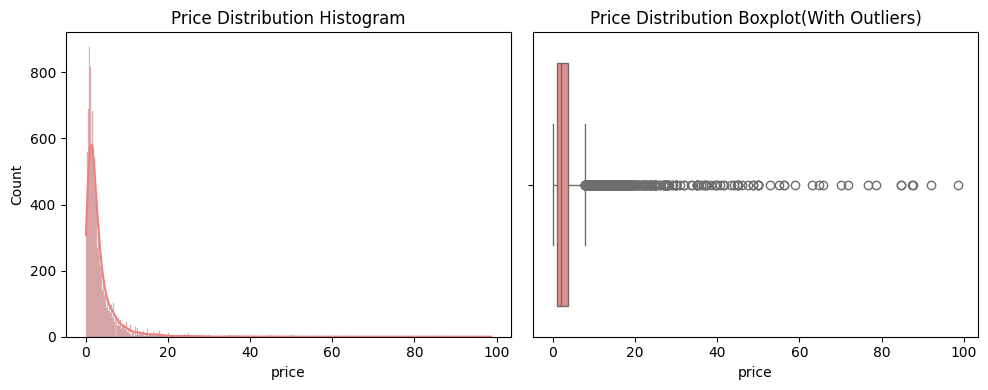

In [52]:

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Number of price outliers (IQR): {len(price_outliers)}")
print(f"Upper Bound for Price: {upper_bound:.2f} Cr")
print(price_outliers['price'].describe())

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(x=df['price'], color='lightcoral', kde=True, ax=ax[0])
ax[0].set_title("Price Distribution Histogram")
sns.boxplot(x=df['price'], color='lightcoral', ax=ax[1])
ax[1].set_title('Price Distribution Boxplot(With Outliers)')

plt.tight_layout()
plt.show()

In [53]:
price_outliers.to_csv('Outliers.csv', index=False)

In [54]:
price_outliers.sort_values('price', ascending=False).head(20)

,bhk,price,age_of_property,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities,age_category
8836,7.00,98.61,1.50,Unknown,Lodha Sea Face,7.00,5.00,1.00,4.50,99acres,Worli Seaface,4540.00,4300.00,True,Unknown,217202.64,3,"Luxury amenities: infinity pool, gym, and more | Live the dream at an affordable price with premium finishes | Safety and privacy with 24/7 security and surveillance",Swimming Pool | Gymnasium | Security | CCTV,Relatively New
5265,6.00,91.98,4.00,Unknown,25 South,6.00,6.00,0.00,4.00,99acres,Prabhadevi,2872.50,2600.00,True,Unknown,320208.88,3,"Oversized land parcels, closest to the Sea, sea-facing flats | Eastern Express Highway connectivity with 2.5 km | Less ground coverage area, more open space",Pet Area | Spa,Relatively New
8365,5.00,87.74,7.00,Unknown,Prestige Nautilus,5.00,4.00,0.00,2.00,99acres,Worli,3050.00,2000.00,True,Unknown,287672.13,3,"24/7 water supply and power backup for uninterrupted living. | Clubhouse, swimming pool, and gymnasium for leisure and fitness. | Proximity to worli metro station (650 m) for easy commuting.",Pet Area | Power Backup | Swimming Pool | Gymnasium | Club House,Mid Age
8993,7.00,87.51,1.50,Unknown,Birla Niyaara,7.00,5.00,1.00,4.50,99acres,Worli,4540.00,4300.00,True,Unknown,192753.30,3,"Lead Architects and Masterplanners: Foster + Partners (London, UK) | Lounge Bar Terrace is provided | 3 Clubhouses For holistic living",Spa | Pet Area | Club House,Relatively New
9818,3.00,84.77,5.00,Unknown,Crest 4 Pali Hill,3.00,3.00,0.00,2.00,99acres,Bandra,1400.00,1073.00,True,Unknown,605500.00,3,Comprehensive wellness hub with gymnasium and swimming pool | Dynamic recreation zones with indoor games and play area | Private social venues with party lawn and steam room,Swimming Pool | Gymnasium | Children's Play Area | Indoor Games | Party Area | Steam Room,Relatively New
10008,6.00,84.65,4.00,Unknown,Provenance Four Seasons Private Residences,6.00,6.00,0.00,4.00,99acres,Worli,2872.50,2600.00,True,Unknown,294691.04,3,"Acre of landscaped space including orchard, pool, BBQ, meditation room | Resident's Club with meeting rooms, lounge, gym, private dining | Membership to The Club at Four Seasons Hotel",Park / Garden | Yoga / Meditation | Spa | Gymnasium | Club House,Relatively New
5725,6.00,78.76,4.00,Unknown,Lodha Sea Face,6.00,6.00,0.00,4.00,99acres,Worli Seaface,2872.50,2600.00,True,Unknown,274186.25,3,"Luxury amenities: infinity pool, gym, and more | Live the dream at an affordable price with premium finishes | Safety and privacy with 24/7 security and surveillance",Swimming Pool | Gymnasium | Security | CCTV,Relatively New
4813,5.00,76.66,7.00,Unknown,West Shore,5.00,4.00,0.00,2.00,99acres,Bandra West,3050.00,2000.00,True,Unknown,251344.26,3,Sustainable utility systems with sewage treatment and rain harvesting | Robust infrastructure with power substation and fire fighting systems | Direct access to Mount Mary Convent High School 220 m,Pet Area | ATM,Mid Age
2996,6.00,71.91,4.00,Unknown,Birla Niyaara,6.00,6.00,0.00,4.00,99acres,Worli,2872.50,2600.00,True,Unknown,250339.43,3,"Lead Architects and Masterplanners: Foster + Partners (London, UK) | Lounge Bar Terrace is provided | 3 Clubhouses For holistic living",Spa | Pet Area | Club House,Relatively New
6581,2.00,70.03,5.00,Unknown,Crest 4 Pali Hill,2.00,2.00,0.00,1.00,99acres,Bandra,900.00,690.00,True,Unknown,778111.11,2,Comprehensive wellness hub with gymnasium and swimming pool | Dynamic recreation zones with indoor games and play area | Private social venues with party lawn and steam room,Swimming Pool | Gymnasium | Children's Play Area | Indoor Games | Party Area | Steam Room,Relatively New


In [55]:
(price_outliers.shape[0]/df.shape[0])*100

8.26865671641791

In [56]:
price_outliers['price_per_sqft'].describe()

,price_per_sqft
count,831.00
mean,62727.80
std,49208.79
min,16666.67
25%,41012.82
50%,51724.14
75%,65811.40
max,778111.11


Number of price outliers (IQR): 556
Upper Bound for Price: 51262.35 Cr
count      556.00
mean     77976.36
std      54631.15
min      51263.00
25%      55618.75
50%      61483.52
75%      75079.55
max     778111.11
Name: price_per_sqft, dtype: float64


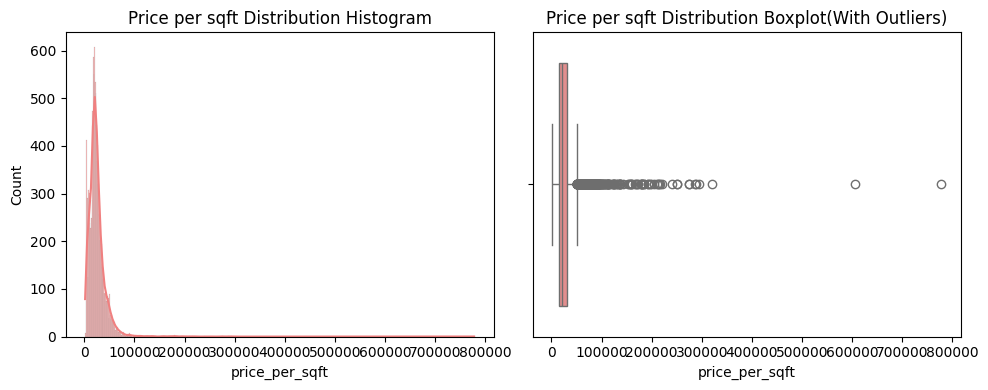

In [57]:

Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]
print(f"Number of price outliers (IQR): {len(price_outliers)}")
print(f"Upper Bound for Price: {upper_bound:.2f} Cr")
print(price_outliers['price_per_sqft'].describe())

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(x=df['price_per_sqft'], color='lightcoral', kde=True, ax=ax[0])
ax[0].set_title("Price per sqft Distribution Histogram")
sns.boxplot(x=df['price_per_sqft'], color='lightcoral', ax=ax[1])
ax[1].set_title('Price per sqft Distribution Boxplot(With Outliers)')

plt.tight_layout()
plt.show()

In [58]:
price_outliers[price_outliers['price_per_sqft']>600000]

,bhk,price,age_of_property,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities,age_category
6581,2.00,70.03,5.00,Unknown,Crest 4 Pali Hill,2.00,2.00,0.00,1.00,99acres,Bandra,900.00,690.00,True,Unknown,778111.11,2,Comprehensive wellness hub with gymnasium and swimming pool | Dynamic recreation zones with indoor games and play area | Private social venues with party lawn and steam room,Swimming Pool | Gymnasium | Children's Play Area | Indoor Games | Party Area | Steam Room,Relatively New
9818,3.00,84.77,5.00,Unknown,Crest 4 Pali Hill,3.00,3.00,0.00,2.00,99acres,Bandra,1400.00,1073.00,True,Unknown,605500.00,3,Comprehensive wellness hub with gymnasium and swimming pool | Dynamic recreation zones with indoor games and play area | Private social venues with party lawn and steam room,Swimming Pool | Gymnasium | Children's Play Area | Indoor Games | Party Area | Steam Room,Relatively New


In [59]:
mask_2bhk = (df['project_name'] == 'Crest 4 Pali Hill') & (df['bhk'] == 2.0)
mask_3bhk = (df['project_name'] == 'Crest 4 Pali Hill') & (df['bhk'] == 3.0)

# Values taken from 99acres website
df.loc[mask_2bhk, 'carpet_area_sqft'] = 1938
df.loc[mask_3bhk, 'carpet_area_sqft'] = 2278

# Calculate buildup_area_sqft (assuming a common conversion factor of ~1.25 if specific factor isn't provided)
# Many real estate standards use Carpet * 1.25 = Build-up
df.loc[mask_2bhk | mask_3bhk, 'buildup_area_sqft'] = df['carpet_area_sqft'] * 1.25


df.loc[mask_2bhk | mask_3bhk, 'price_per_sqft'] = (df['price'] * 10000000) / df['carpet_area_sqft']

display(df[df['project_name'] == 'Crest 4 Pali Hill'][['project_name', 'bhk', 'price', 'carpet_area_sqft', 'buildup_area_sqft', 'price_per_sqft']])

,project_name,bhk,price,carpet_area_sqft,buildup_area_sqft,price_per_sqft
6581,Crest 4 Pali Hill,2.00,70.03,1938.00,2422.50,361351.91
9818,Crest 4 Pali Hill,3.00,84.77,2278.00,2847.50,372124.67


In [60]:
# Identify top 10 locations based on median price per sqft (Premium Areas)
top_premium_locs = df.groupby('location')['price_per_sqft'].median().sort_values(ascending=False).head(10).index

# Create the validation pivot for these premium locations
premium_validation = df[df['location'].isin(top_premium_locs)].pivot_table(
    index=['location', 'bhk'],
    values=['carpet_area_sqft', 'buildup_area_sqft'],
    aggfunc='median'
)

premium_validation['ratio'] = premium_validation['buildup_area_sqft'] / premium_validation['carpet_area_sqft']

print("Validation for Top 10 Premium Locations (by Price):")
display(premium_validation)

Validation for Top 10 Premium Locations (by Price):


buildup_area_sqft  carpet_area_sqft  ratio
location      bhk                                             
Churchgate    2.00            1152.50           1030.00   1.12
              3.00            2100.00           1073.00   1.96
Cumballa Hill 2.00            1170.00            690.00   1.70
              3.00            1800.00           1073.00   1.68
              4.00            2594.00           1715.00   1.51
              6.00            4400.00           3962.00   1.11
Gamdevi       2.00             975.00            845.00   1.15
              3.00            1275.00           1073.00   1.19
Grant Road    2.00             900.00            690.00   1.30
              3.00            1400.00           1073.00   1.30
              4.00            2200.00           1715.00   1.28
Mahalaxmi     2.00             900.00            690.00   1.30
              3.00            1400.00           1073.00   1.30
              4.00            2200.00           1715.00   1.28
              5.00            3050.00           2000.00   1.52
              6.00            2872.50           2600.00   1.10
Malabar Hill  1.00             785.00            425.00   1.85
              2.00            1350.00            945.00   1.43
              3.00            1690.00           1073.00   1.58
              4.00            2400.00           1715.00   1.40
              6.00            2872.50           2600.00   1.10
Marine Lines  2.00             900.00            690.00   1.30
              3.00            1400.00           1073.00   1.30
              4.00            2200.00           1715.00   1.28
              5.00            3050.00           2000.00   1.52
Tardeo        1.00             442.50            425.00   1.04
              2.00            1242.00            938.00   1.32
              3.00            1400.00           1073.00   1.30
              4.00            2250.00           1957.50   1.15
              5.00            3050.00           2000.00   1.52
Worli         1.00             700.00            524.00   1.34
              2.00             900.00            690.00   1.30
              3.00            1500.00           1073.00   1.40
              4.00            2200.00           1715.00   1.28
              5.00            3050.00           2000.00   1.52
              6.00            2872.50           2600.00   1.10
              7.00            3770.00           3600.00   1.05
Worli Seaface 3.00            1400.00           1073.00   1.30
              4.00            2200.00           1715.00   1.28
              5.00            3050.00           2000.00   1.52
              6.00            2872.50           2600.00   1.10
              7.00            4540.00           4300.00   1.06

Number of price outliers (IQR): 556
Upper Bound for Price: 51262.35 Cr
count      556.00
mean     76807.06
std      43579.22
min      51263.00
25%      55618.75
50%      61483.52
75%      75079.55
max     372124.67
Name: price_per_sqft, dtype: float64


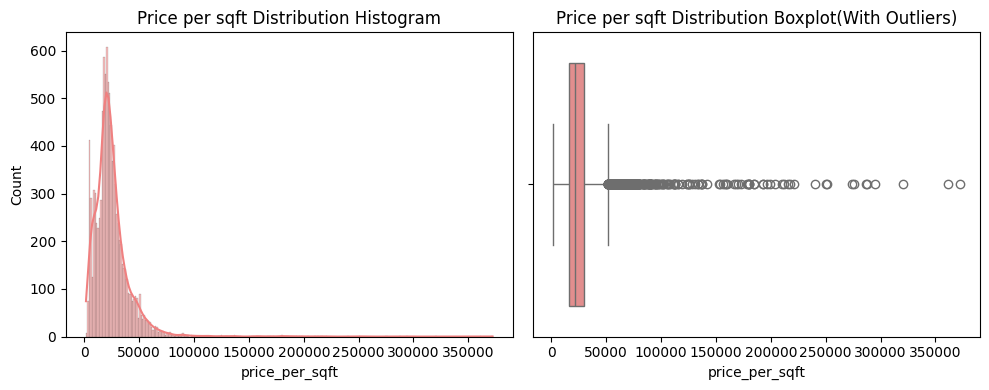

In [61]:
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]
print(f"Number of price outliers (IQR): {len(price_outliers)}")
print(f"Upper Bound for Price: {upper_bound:.2f} Cr")
print(price_outliers['price_per_sqft'].describe())

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(x=df['price_per_sqft'], color='lightcoral', kde=True, ax=ax[0])
ax[0].set_title("Price per sqft Distribution Histogram")
sns.boxplot(x=df['price_per_sqft'], color='lightcoral', ax=ax[1])
ax[1].set_title('Price per sqft Distribution Boxplot(With Outliers)')

plt.tight_layout()
plt.show()

In [62]:
# Correct syntax to find the 95th percentile of the price column
price_95th_percentile = df['price'].quantile(0.95)
print(f"The 95th percentile for price is: {price_95th_percentile:.2f} Cr")

The 95th percentile for price is: 10.00 Cr


In [63]:
df[df['price']>price_95th_percentile].shape

(502, 20)

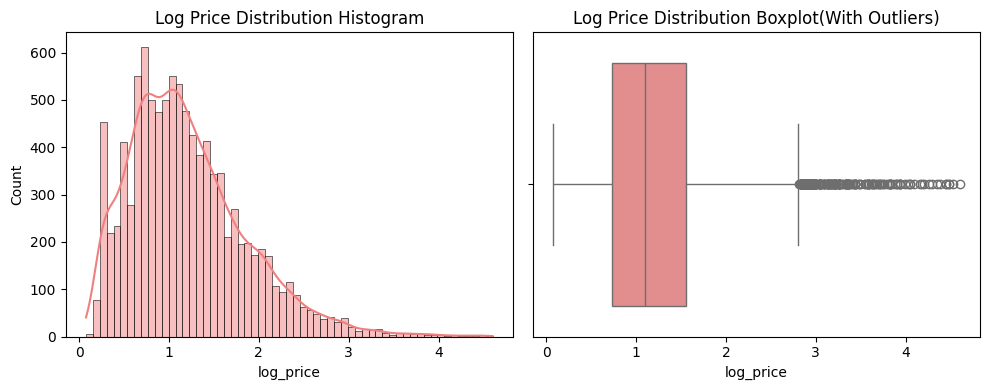

In [64]:
df_model = df.copy()
df_model['log_price'] = np.log1p(df['price'])

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(x=df_model['log_price'], color='lightcoral', kde=True, ax=ax[0])
ax[0].set_title("Log Price Distribution Histogram")
sns.boxplot(x=df_model['log_price'], color='lightcoral', ax=ax[1])
ax[1].set_title('Log Price Distribution Boxplot(With Outliers)')

plt.tight_layout()
plt.show()

In [65]:
df_model['log_price'].skew()

np.float64(1.0044585824091683)

In [66]:
df['log_price'] = np.log1p(df['price'])

Q1 = df['log_price'].quantile(0.25)
Q3 = df['log_price'].quantile(0.75)
IQR = Q3 - Q1

# keeping range of 3*IQR
df = df[
    (df['log_price'] >= Q1 - 3*IQR) &
    (df['log_price'] <= Q3 + 3*IQR)
]

print(f"Removed: {len(df_copy) - len(df)} rows")
print(f"Upper bound: {np.expm1(Q3 + 3*IQR):.2f} Cr")

Removed: 14 rows
Upper bound: 56.39 Cr


In [67]:
df.to_csv("Outliers_removed_real_estate.csv", index=False)
print("CSV updated with the latest DataFrame changes.")

CSV updated with the latest DataFrame changes.


In [68]:
Q1 = df_model['log_price'].quantile(0.25)
Q3 = df_model['log_price'].quantile(0.75)
IQR = Q3 - Q1

# keeping range of 3*IQR
df_model = df_model[
    (df_model['log_price'] >= Q1 - 3*IQR) &
    (df_model['log_price'] <= Q3 + 3*IQR)
]

print(f"Removed: {len(df) - len(df_model)} rows")
print(f"Upper bound: {np.expm1(Q3 + 3*IQR):.2f} Cr")

Removed: 0 rows
Upper bound: 56.39 Cr


In [69]:
# Checking removed properties
removed_indices = df.index.difference(df_model.index)
removed_rows = df.loc[removed_indices]

print(f"Displaying the {len(removed_rows)} removed rows (outliers):")
display(removed_rows.sort_values('price', ascending=False))

Displaying the 0 removed rows (outliers):


,bhk,price,age_of_property,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities,age_category,log_price


In [70]:
print(df_model['log_price'].skew())

0.909720530846253


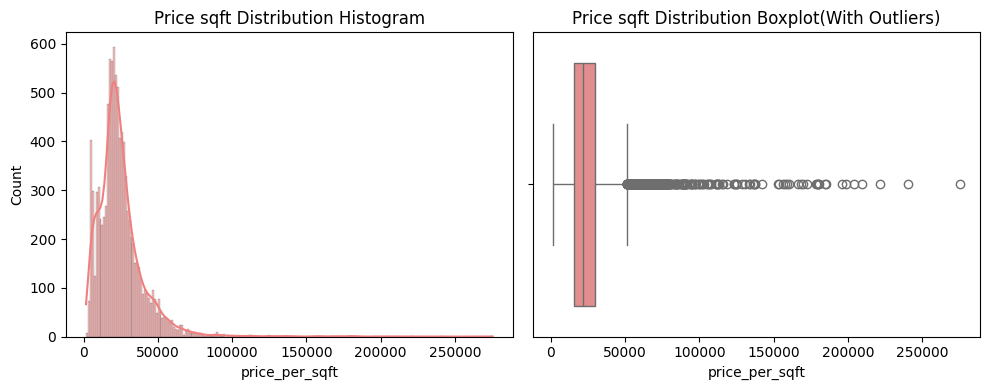

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(x=df_model['price_per_sqft'], color='lightcoral', kde=True, ax=ax[0])
ax[0].set_title("Price sqft Distribution Histogram")
sns.boxplot(x=df_model['price_per_sqft'], color='lightcoral', ax=ax[1])
ax[1].set_title('Price sqft Distribution Boxplot(With Outliers)')

plt.tight_layout()
plt.show()

In [72]:
df_model['log_price_per_sqft'] = np.log1p(df_model['price_per_sqft'])
print(df_model[['log_price', 'log_price_per_sqft']].corr())

                    log_price  log_price_per_sqft
log_price                1.00                0.84
log_price_per_sqft       0.84                1.00


In [73]:
num_cols = ['price_per_sqft', 'buildup_area_sqft', 'carpet_area_sqft',
            'bathrooms', 'balcony', 'parking', 'age_of_property',
            'bedrooms', 'bhk', 'property_score']

print(df_model[num_cols].skew().sort_values(ascending=False))

price_per_sqft      3.51
buildup_area_sqft   3.13
carpet_area_sqft    2.66
age_of_property     2.57
balcony             1.68
parking             1.38
bathrooms           1.01
bedrooms            0.70
bhk                 0.60
property_score      0.54
dtype: float64


In [74]:
df_model[df_model['price_per_sqft']>=200000][['bhk', 'price','price_per_sqft', 'location']]

,bhk,price,price_per_sqft,location
5014,4.00,44.88,204000.00,Worli
7095,4.00,48.70,221363.64,Worli
8762,4.00,46.14,209727.27,Juhu
9104,3.00,38.55,275357.14,Worli
9474,4.00,52.95,240681.82,Prabhadevi


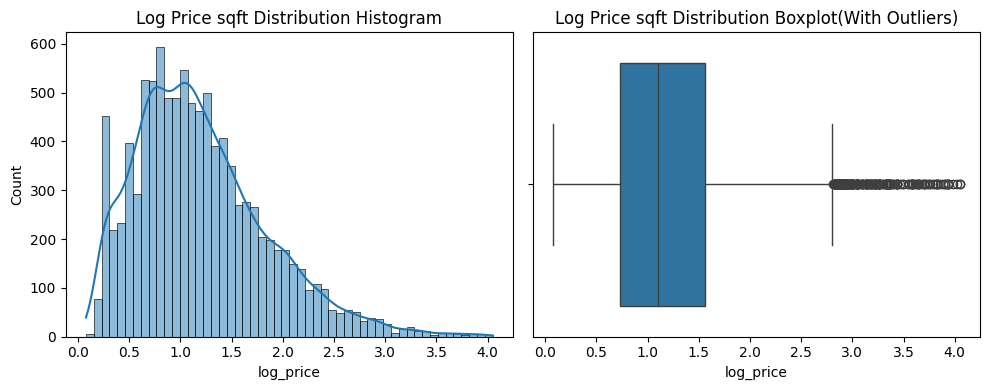

0.909720530846253


In [75]:
df_model['log_price_per_sqft'] = np.log1p(df_model['price'])

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(x=df_model['log_price'], kde=True, ax=ax[0])
ax[0].set_title("Log Price sqft Distribution Histogram")
sns.boxplot(x=df_model['log_price'], ax=ax[1])
ax[1].set_title('Log Price sqft Distribution Boxplot(With Outliers)')

plt.tight_layout()
plt.show()

print(df_model['log_price_per_sqft'].skew())

- So applying log on price and price_per_sqft is giving same skewness

In [76]:
df_model.head()

,bhk,price,age_of_property,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities,age_category,log_price,log_price_per_sqft
0,3.00,2.05,15.00,Middle,Moroccan Cooperative,3.00,3.00,3.00,1.00,kaggle,Goregaon East,1862.00,1425.00,True,Semi Furnished,11009.67,4,NaN,NaN,Mid Age,1.12,1.12
1,1.00,1.33,1.00,Lower,Rajesh White City,1.00,2.00,0.00,1.00,kaggle,Kandivali East,790.00,479.00,True,Unfurnished,16835.44,1,NaN,NaN,New,0.85,0.85
2,3.00,7.30,10.00,Lower,Oberoi Esquire,3.00,2.00,0.00,2.00,kaggle,Goregaon East,1430.00,1330.00,True,Unfurnished,51048.95,3,NaN,NaN,Mid Age,2.12,2.12
3,3.00,7.60,4.00,Higher,Oberoi Esquire,3.00,4.00,0.00,3.00,kaggle,Goregaon East,2195.00,1400.00,True,Semi Furnished,34624.15,5,NaN,NaN,Relatively New,2.15,2.15
4,2.00,3.20,3.00,Lower,Ajmera Zeon,2.00,2.00,1.00,1.00,kaggle,Wadala East,960.00,860.00,True,Unfurnished,33333.33,3,NaN,NaN,Relatively New,1.44,1.44


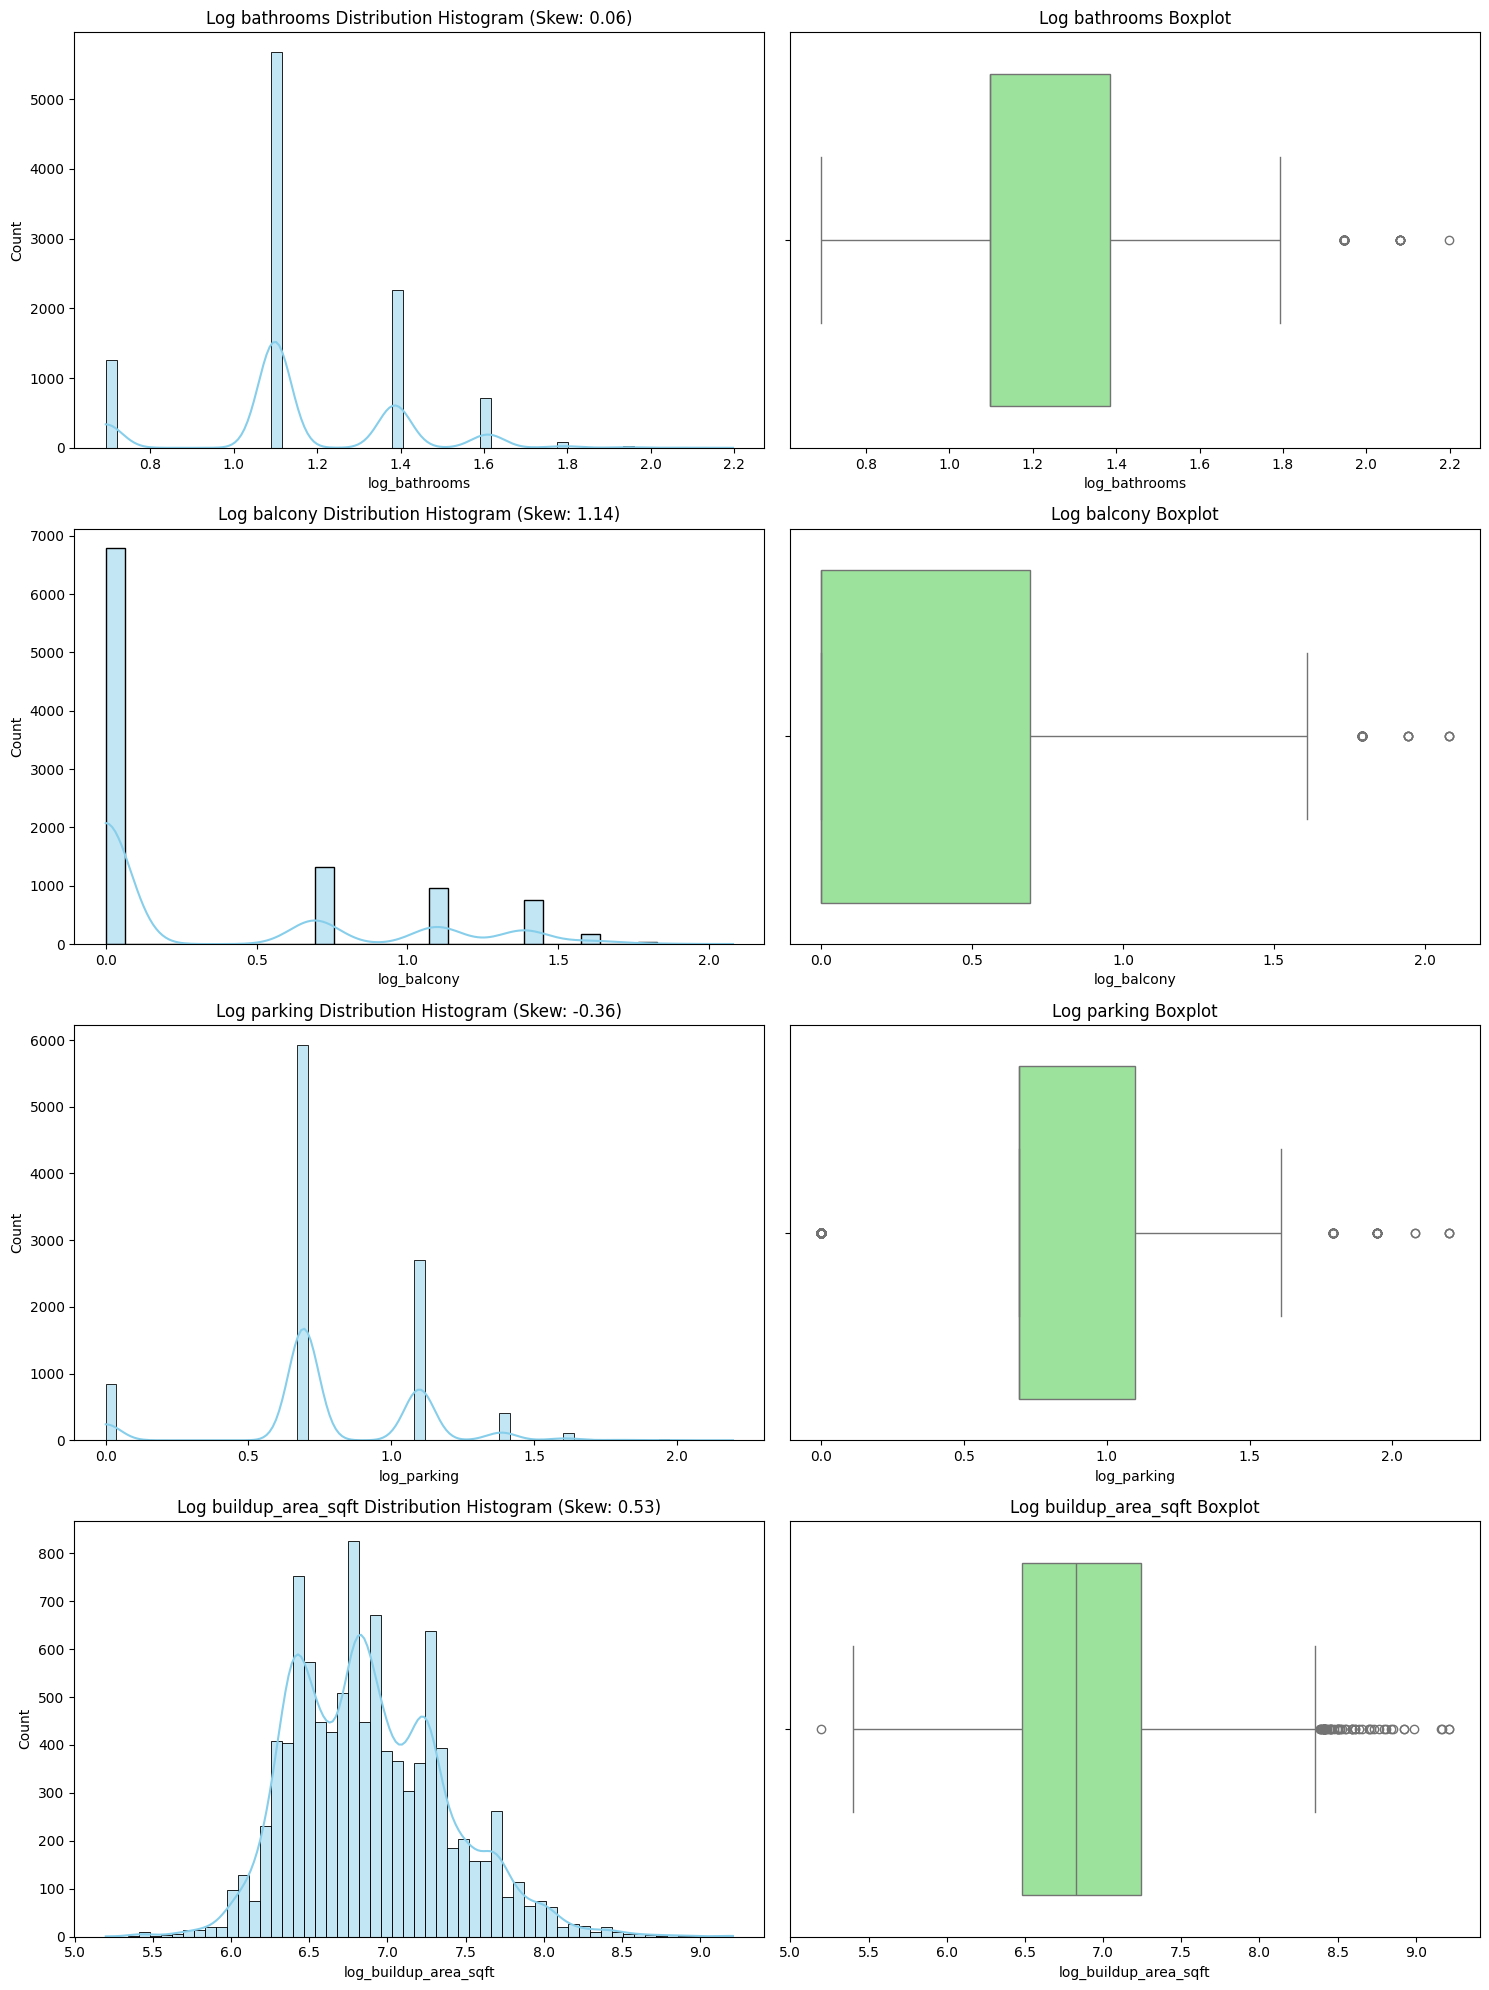

In [77]:
cols = ['bathrooms', 'balcony', 'parking', 'buildup_area_sqft']

fig, axes = plt.subplots(len(cols), 2, figsize=(15, 20))
axes = axes.flatten() # Flatten 2D array to 1D for easier indexing

for i, col in enumerate(cols):
    df_model[f'log_{col}'] = np.log1p(df_model[col])

    # Histogram in the first column of the row
    sns.histplot(x=df_model[f'log_{col}'], kde=True, ax=axes[2*i], color='skyblue')
    axes[2*i].set_title(f"Log {col} Distribution Histogram (Skew: {df_model[f'log_{col}'].skew():.2f})")

    # Boxplot in the second column of the row
    sns.boxplot(x=df_model[f'log_{col}'], ax=axes[2*i + 1], color='lightgreen')
    axes[2*i + 1].set_title(f'Log {col} Boxplot')

plt.tight_layout()
plt.show()

In [78]:
df_model[df_model['log_buildup_area_sqft'] > 8.5][['project_name','bhk','buildup_area_sqft','price']]

,project_name,bhk,buildup_area_sqft,price
851,Omkar Alta Monte,5.00,6600.00,11.00
964,45.0 LacsAccess Zero Brokerage Properties,4.00,6200.00,45.00
977,Sunteck Signature Island,6.00,7000.00,35.00
1237,30.0 LacsAccess Zero Brokerage Properties,6.00,5400.00,30.00
1339,Indiabulls Sky Forest A3,6.00,9600.00,50.00
1650,Indiabulls Blu Tower B,4.00,5000.00,45.00
2839,Capri Heights,5.00,8000.00,29.00
3349,Indiabulls Blu Tower C,6.00,9500.00,50.00
3950,25.0 LacsAccess Zero Brokerage Properties,5.00,5501.00,25.00
4035,Lodha The World Towers World One Tier II,5.00,7500.00,32.00


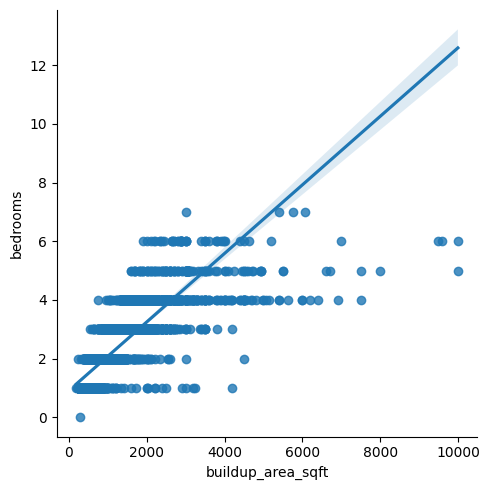

In [79]:
sns.lmplot(data=df_model, x='buildup_area_sqft', y = 'bedrooms')

- There are nearly no properties which are less 2000 sqft area and are having more than 6 bedrooms. So we can conclude that data is cleaned.

<Axes: xlabel='buildup_area_sqft', ylabel='carpet_area_sqft'>

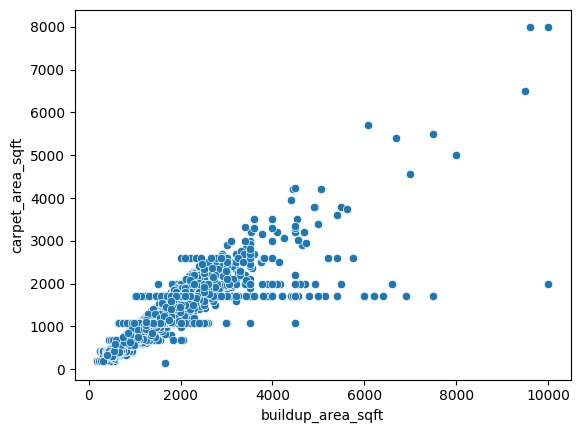

In [80]:
sns.scatterplot(df_model, x='buildup_area_sqft', y='carpet_area_sqft')

In [81]:
df_model.sample(5)

,bhk,price,age_of_property,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities,age_category,log_price,log_price_per_sqft,log_bathrooms,log_balcony,log_parking,log_buildup_area_sqft
5065,3.00,5.18,5.00,Unknown,Rajadhiraj Mansion 835,3.00,3.00,0.00,2.00,99acres,Dadar West,1400.00,1073.00,True,Unknown,37000.00,3,Residences featuring three private balconies for maximum cross-ventilation | Ground floor wellness zone with reflexology path and outdoor walking trail | Terrace-level social space with a party lawn and dedicated bar counter,Pet Area | Party Area | Spa,Relatively New,1.82,1.82,1.39,0.00,1.10,7.24
4033,2.00,3.13,5.00,Lower,DB Woods,2.00,2.00,2.00,1.00,kaggle,Goregaon East,1113.00,891.00,True,Unfurnished,28122.19,2,NaN,NaN,Relatively New,1.42,1.42,1.10,1.10,0.69,7.02
4073,2.00,2.10,5.00,Middle,Nahar Cayenne,2.00,2.00,0.00,1.00,kaggle,Powai,1150.00,752.00,True,Fully Furnished,18260.87,3,NaN,NaN,Relatively New,1.13,1.13,1.10,0.00,0.69,7.05
9203,1.00,2.10,40.00,Lower,2.1 LacsAccess Zero Brokerage Properties,2.00,2.00,0.00,0.00,kaggle,Cuffe Parade,555.00,425.00,True,Unfurnished,37837.84,3,NaN,NaN,Old,1.13,1.13,1.10,0.00,0.00,6.32
9295,2.00,2.20,10.00,Middle,Mayfair Greens,2.00,2.00,0.00,1.00,kaggle,Kandivali West,1000.00,870.00,True,Semi Furnished,22000.00,2,NaN,NaN,Mid Age,1.16,1.16,1.10,0.00,0.69,6.91
